# EDA temporal

```{admonition} Alcance
:class: tip
Este capítulo usa solo el entrenamiento: 16 meses, de enero de 2025 a abril de 2026. Con una serie
tan corta las pruebas tienen poca potencia, y sus resultados se leen como indicios.
```

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.formula.api import logit

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
from comun import (cargar, particion, estilo, tasa_ic, etiquetar, puntos, OBJETIVO, NUM,
                   PREDICTORAS, NOMBRE, VERDE, ORO, GRIS, BORDE)

estilo()

tr, _ = particion(cargar())
serie = tasa_ic(tr, 'mes')
serie.index = pd.PeriodIndex(serie.index, freq='M')

## La serie mensual

Primero verificamos la variable temporal: formato, frecuencia, huecos y duplicados.

In [2]:
meses = pd.PeriodIndex(tr.mes.unique(), freq='M').sort_values()
esperados = pd.period_range(meses.min(), meses.max(), freq='M')
huecos = sorted(set(esperados) - set(meses)) or 'ninguno'
filas_mes = tr.groupby('mes').size()
print('formato: AAAA-MM, sin zona horaria (foto del día 1 de cada mes) | frecuencia: mensual')
print(f'meses: {len(meses)} de {len(esperados)} esperados entre {meses.min()} y {meses.max()} | '
      f'huecos: {huecos}')
print(f'persona-mes repetidas: {int(tr.duplicated(["persona_id", "mes"]).sum())}')
print(f'filas por mes: mínimo {filas_mes.min():,}, máximo {filas_mes.max():,}')

formato: AAAA-MM, sin zona horaria (foto del día 1 de cada mes) | frecuencia: mensual
meses: 16 de 16 esperados entre 2025-01 y 2026-04 | huecos: ninguno
persona-mes repetidas: 0
filas por mes: mínimo 3,992, máximo 4,433


La serie es mensual y regular, sin huecos ni duplicados. El número de personas activas crece de
forma suave (de 3.992 a 4.433), sin saltos que indiquen cargas incompletas.

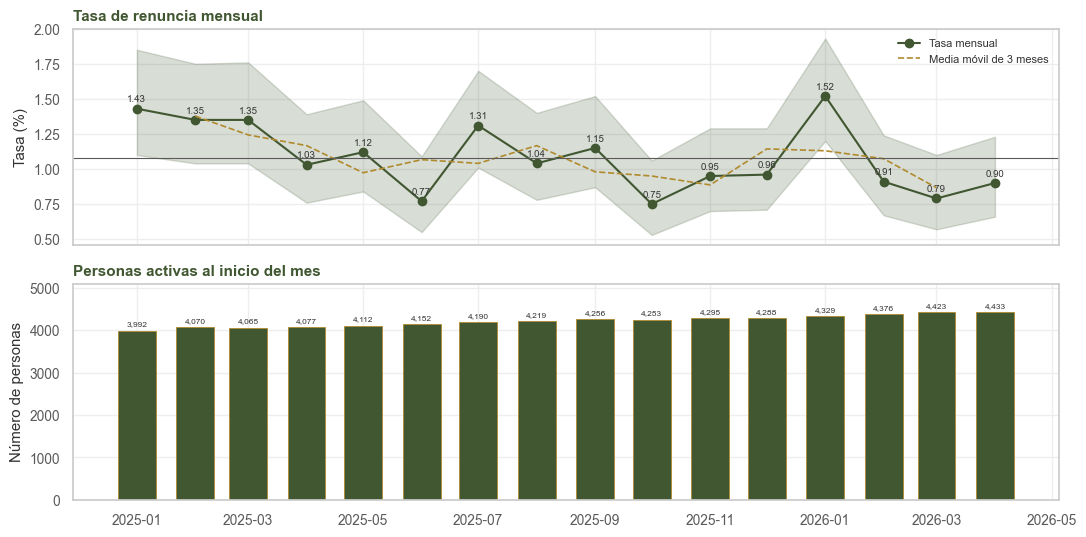

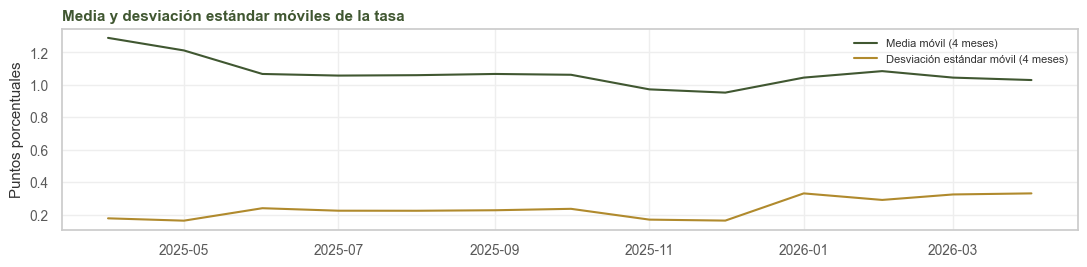

mes,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04
filas,3992.00,4070.00,4065.00,4077.00,4112.00,4152.00,4190.00,4219.00,4256.00,4253.00,4295.00,4288.00,4329.00,4376.00,4423.00,4433.00
renuncias,57.00,55.00,55.00,42.00,46.00,32.00,55.00,44.00,49.00,32.00,41.00,41.00,66.00,40.00,35.00,40.00
tasa_%,1.43,1.35,1.35,1.03,1.12,0.77,1.31,1.04,1.15,0.75,0.95,0.96,1.52,0.91,0.79,0.90
ic_bajo,1.10,1.04,1.04,0.76,0.84,0.55,1.01,0.78,0.87,0.53,0.70,0.71,1.20,0.67,0.57,0.66
ic_alto,1.85,1.75,1.76,1.39,1.49,1.09,1.70,1.40,1.52,1.06,1.29,1.29,1.93,1.24,1.10,1.23


In [3]:
x = serie.index.to_timestamp()

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax[0].plot(x, serie['tasa_%'], marker='o', color=VERDE, label='Tasa mensual')
ax[0].fill_between(x, serie.ic_bajo, serie.ic_alto, alpha=0.2, color=VERDE)
puntos(ax[0], x, serie['tasa_%'])
ax[0].plot(x, serie['tasa_%'].rolling(3, center=True).mean(), ls='--', c=ORO, lw=1.2,
           label='Media móvil de 3 meses')
ax[0].axhline(100 * tr[OBJETIVO].mean(), c=GRIS, lw=0.8)
ax[0].legend(fontsize=8)
ax[0].set(title='Tasa de renuncia mensual', ylabel='Tasa (%)')

barras = ax[1].bar(x, serie.filas, width=20, color=VERDE, **BORDE)
etiquetar(ax[1], barras, '{:,.0f}', fontsize=6)
ax[1].set(title='Personas activas al inicio del mes', ylabel='Número de personas')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.plot(x, serie['tasa_%'].rolling(4).mean(), label='Media móvil (4 meses)')
ax.plot(x, serie['tasa_%'].rolling(4).std(), label='Desviación estándar móvil (4 meses)')
ax.set(title='Media y desviación estándar móviles de la tasa', ylabel='Puntos porcentuales')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

serie[['filas', 'renuncias', 'tasa_%', 'ic_bajo', 'ic_alto']].T

## Estacionalidad

Una descomposición STL con periodo anual necesita al menos dos ciclos completos (24 meses) y aquí
hay 16, por lo que la componente estacional no se puede estimar. Comparamos en cambio los cuatro meses
que aparecen en los dos años (enero a abril de 2025 y de 2026).

In [4]:
d = tr.assign(anio=tr.mes.str[:4], m=tr.mes.str[5:].astype(int))
dos_anios = d[d.m <= 4].pivot_table(index='m', columns='anio', values=OBJETIVO, aggfunc='mean')
dos_anios = dos_anios * 100
dos_anios.index = ['ene', 'feb', 'mar', 'abr']
print(dos_anios.round(2).to_string())
rho = stats.spearmanr(dos_anios['2025'], dos_anios['2026'])[0]
print(f'\ncorrelación de rangos entre los dos años (4 meses): {rho:.2f}')

# enero frente al resto del año
d['enero'] = d.mes.str[5:] == '01'
chi, pv = stats.chi2_contingency(pd.crosstab(d.enero, d[OBJETIVO]).to_numpy(), correction=False)[:2]
t_enero = tasa_ic(d, d.enero.map({True: 'enero', False: 'resto del año'}))
razon = t_enero.loc['enero', 'tasa_%'] / t_enero.loc['resto del año', 'tasa_%']
print(t_enero.to_string())
print(f'chi-cuadrado enero frente al resto: {chi:.1f}, p = {pv:.4f}; razón de tasas {razon:.2f}')

anio  2025  2026
ene   1.43  1.52
feb   1.35  0.91
mar   1.35  0.79
abr   1.03  0.90

correlación de rangos entre los dos años (4 meses): 0.40
               filas  renuncias  tasa_%  ic_bajo  ic_alto
enero                                                    
enero           8321        123    1.48     1.24     1.76
resto del año  59209        607    1.03     0.95     1.11
chi-cuadrado enero frente al resto: 14.0, p = 0.0002; razón de tasas 1.44


Enero es el mes más alto en los dos años (1,48 % frente a 1,03 %). Es coherente con el calendario
laboral colombiano: la prima de diciembre y las vacaciones de fin de año se cobran antes de cambiar
de trabajo. Con dos repeticiones no es una estacionalidad demostrada, pero justifica incluir el mes
del año como variable del modelo.

## Estacionariedad y autocorrelación

Las pruebas ADF y KPSS tienen hipótesis nulas opuestas: ADF supone raíz unitaria (serie no
estacionaria) y KPSS supone estacionariedad. Leerlas juntas evita tomar un "no rechazo" como una
confirmación.

ADF:  estadístico -3.65, p = 0.005  (H0: raíz unitaria)
KPSS: estadístico 0.35, p = 0.097  (H0: estacionaria; p acotado entre 0,01 y 0,10 por la tabla)


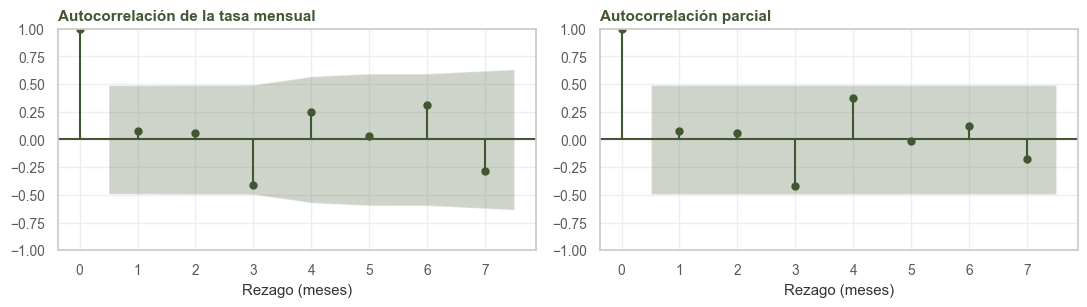

In [5]:
y_serie = serie['tasa_%'].to_numpy()
adf = adfuller(y_serie, maxlag=2, autolag=None)
kp = kpss(y_serie, regression='c', nlags=2)
print(f'ADF:  estadístico {adf[0]:.2f}, p = {adf[1]:.3f}  (H0: raíz unitaria)')
print(f'KPSS: estadístico {kp[0]:.2f}, p = {kp[1]:.3f}  '
      f'(H0: estacionaria; p acotado entre 0,01 y 0,10 por la tabla)')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
plot_acf(y_serie, lags=7, ax=ax[0], color=VERDE, vlines_kwargs={'colors': VERDE})
plot_pacf(y_serie, lags=7, ax=ax[1], method='ywm', color=VERDE, vlines_kwargs={'colors': VERDE})
ax[0].set(title='Autocorrelación de la tasa mensual', xlabel='Rezago (meses)')
ax[1].set(title='Autocorrelación parcial', xlabel='Rezago (meses)')
plt.tight_layout()
plt.show()

ADF rechaza la raíz unitaria (p = 0,005) y KPSS no rechaza la estacionariedad (p ≈ 0,10); ambas
apuntan a una serie estacionaria en nivel, que oscila alrededor de su media sin tendencia. Con 16
puntos, las bandas de la autocorrelación son anchas (±0,5) y ninguna la supera: no hay evidencia de
que la tasa agregada de un mes anticipe la del siguiente, y no se agregan rezagos de la tasa
global como variables.

Tampoco hay un cambio de régimen visible: la serie no muestra saltos de nivel y las dos pruebas son
compatibles con una media constante. Con 16 puntos no se puede fechar un punto de cambio con
precisión, y una diferencia moderada de nivel pasaría inadvertida. El test (0,92 % mensual) queda
algo por debajo del entrenamiento (1,08 %); su efecto sobre el modelo se revisa en los residuos del
capítulo 7. El efecto de calendario identificado es el de enero (sección 5.2).

## Deriva de la población

Para un corte temporal, el riesgo principal es que la población cambie: si el test tiene otra mezcla
de contratos o de antigüedades, el modelo se evalúa sobre personas distintas de las que usó para
aprender. Lo medimos con el índice de estabilidad poblacional (PSI) entre el primer semestre de 2025
y los meses de 2026 del entrenamiento. Con $a_j$ y $b_j$ la proporción de filas en la categoría (o
el tramo) *j* en cada periodo,

$$
\text{PSI} = \sum_{j} (a_j - b_j) \ln \frac{a_j}{b_j} ,
$$

que es una versión simétrica de la divergencia de Kullback-Leibler. La regla usual es: PSI < 0,1
estable, de 0,1 a 0,25 cambio moderado y > 0,25 cambio grande.

In [6]:
def psi(a, b):
    pa = a.value_counts(normalize=True)
    pb = b.value_counts(normalize=True)
    categorias = pa.index.union(pb.index)
    pa = pa.reindex(categorias).fillna(0) + 1e-4
    pb = pb.reindex(categorias).fillna(0) + 1e-4
    return float(((pa - pb) * np.log(pa / pb)).sum())


inicio = tr[tr.mes <= '2025-06']
fin = tr[tr.mes >= '2026-01']
filas = []
for v in PREDICTORAS:
    a, b = inicio[v], fin[v]
    if v in NUM:
        cortes = np.unique(np.quantile(tr[v].dropna(), np.linspace(0, 1, 11)))
        a = pd.cut(a, cortes, include_lowest=True)
        b = pd.cut(b, cortes, include_lowest=True)
    filas.append({'variable': v, 'PSI': psi(a.astype(str), b.astype(str))})
deriva = pd.DataFrame(filas).set_index('variable').sort_values('PSI', ascending=False)
deriva['lectura'] = pd.cut(deriva.PSI, [-1, 0.1, 0.25, 99],
                           labels=['estable', 'moderado', 'grande'])
deriva.round(3)

variable,PSI,lectura
antig_meses,0.355,grande
sociedad,0.174,moderado
ubicacion,0.038,estable
oficio,0.016,estable
proceso_planta,0.015,estable
contrato,0.012,estable
traslado_12m,0.006,estable
area_funcional,0.004,estable
familia_cargo,0.003,estable
nivel,0.003,estable


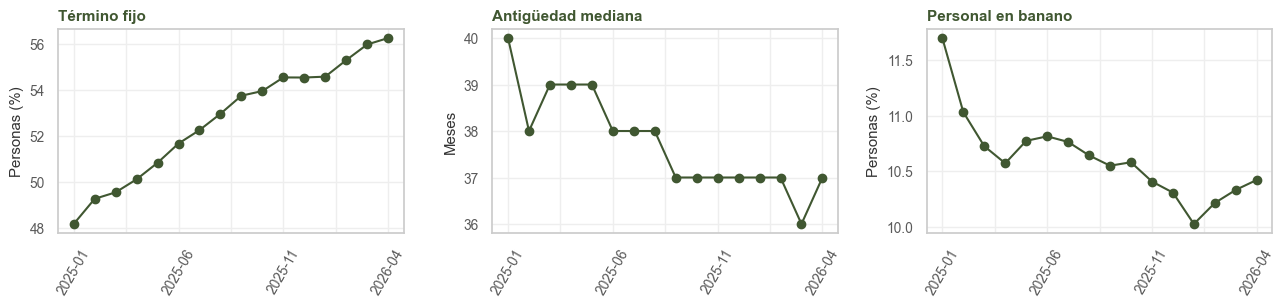

In [7]:
por_mes = tr.groupby('mes')
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
(100 * por_mes.contrato.apply(lambda z: (z == 'Termino Fijo').mean())).plot(ax=ax[0], marker='o')
ax[0].set(title='Término fijo', xlabel='', ylabel='Personas (%)')
por_mes.antig_meses.median().plot(ax=ax[1], marker='o')
ax[1].set(title='Antigüedad mediana', xlabel='', ylabel='Meses')
(100 * por_mes.linea.apply(lambda z: (z == 'banano').mean())).plot(ax=ax[2], marker='o')
ax[2].set(title='Personal en banano', xlabel='', ylabel='Personas (%)')
for a in ax:
    a.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

Dos variables superan el umbral de estabilidad, en ambos casos por razones distintas a un cambio en
la composición del personal:

- `antig_meses` (PSI 0,36) refleja el envejecimiento del panel. Una cohorte grande que en 2025 tenía
  entre 66 y 85 meses (15 % de las filas) pasó en 2026 al tramo de 85 a 108: son las mismas personas
  con un año más, y la mediana casi no cambia (de 40 a 37 meses). En el test habrá más personas con
  antigüedad alta, donde el riesgo es menor y más estable.
- `sociedad` (PSI 0,17) corresponde a un traslado de nómina: S09 pasa de 3,8 % a 0,1 % de las filas
  y S05 sube de 6,2 % a 10,0 %, mientras la línea de negocio se mantiene (PSI 0,003). Si una
  sociedad desaparece en el test, el modelo pierde su estimación; conviene que no dependa
  solo de esta variable.

## Composición del mes y tasa futura

Agregamos por mes algunas características de la población y las correlacionamos con la tasa del
mismo mes y de los tres siguientes: una correlación cruzada entre cada predictora agregada y el
objetivo con rezagos de 0 a 3 meses, $
ho_k = \operatorname{corr}(x_t, y_{t+k})$. Con 16 meses, una correlación debe superar ±0,5 aproximadamente
para distinguirse del azar.

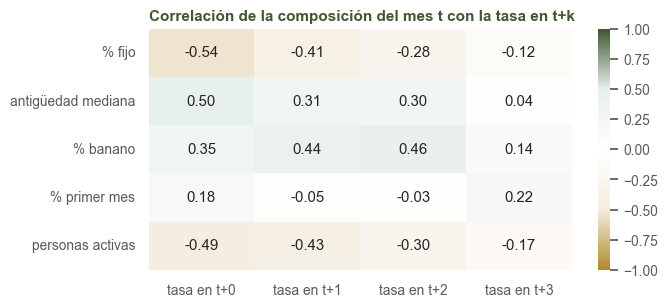

In [8]:
agregado = pd.DataFrame({
    '% fijo': 100 * por_mes.contrato.apply(lambda z: (z == 'Termino Fijo').mean()),
    'antigüedad mediana': por_mes.antig_meses.median(),
    '% banano': 100 * por_mes.linea.apply(lambda z: (z == 'banano').mean()),
    '% primer mes': 100 * por_mes.primer_mes.mean(),
    'personas activas': por_mes.size(),
})
tasa_mes = 100 * por_mes[OBJETIVO].mean()
cruzada = pd.DataFrame({v: [agregado[v].corr(tasa_mes.shift(-k)) for k in range(4)]
                        for v in agregado}, index=[f'tasa en t+{k}' for k in range(4)]).T

fig, ax = plt.subplots(figsize=(7, 3.2))
sns.heatmap(cruzada, annot=True, fmt='.2f', cmap='oro_verde', center=0, vmin=-1, vmax=1, ax=ax)
ax.set(title='Correlación de la composición del mes t con la tasa en t+k')
plt.tight_layout()
plt.show()

Las correlaciones más altas están en el límite del azar y tienen el signo contrario al efecto
individual: los meses con más término fijo tienen menos renuncias (−0,54), aunque a nivel de persona
el término fijo renuncia 3,7 veces más. La diferencia corresponde a una falacia ecológica: a lo largo
de la ventana crecen la población activa y la proporción de término fijo mientras la tasa desciende
levemente. La composición agregada del mes no anticipa la tasa, y no se incluyen rezagos agregados.

## Deriva del concepto

El PSI mide si cambian las predictoras (*covariate shift*). Aquí se examina si cambia la relación
entre las predictoras y la renuncia (*concept drift*), comparando la tasa por contrato y por tramo de
antigüedad en tres periodos del entrenamiento.

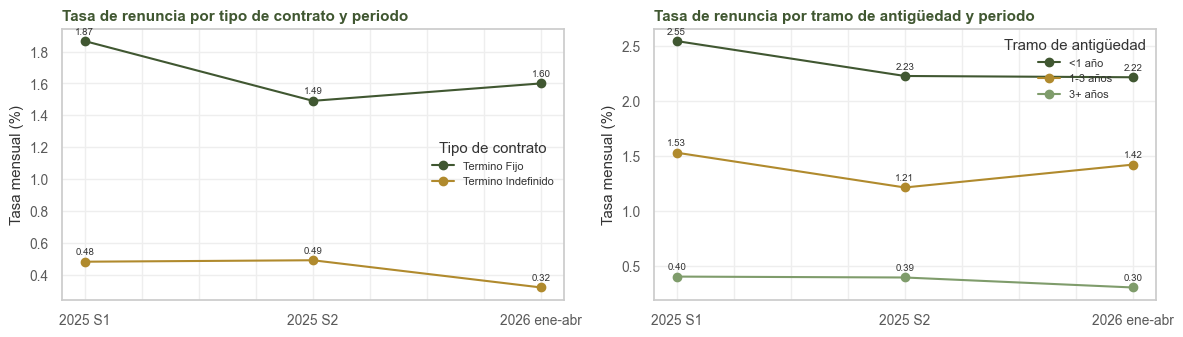

razón de tasas fijo / indefinido por periodo: {'2025 S1': 3.87, '2025 S2': 3.04, '2026 ene-abr': 5.0}


razón de verosimilitud para la interacción contrato × periodo: 3.91 con 2 gl, p = 0.141


In [9]:
indice_mes = tr.mes.map(lambda m: int(m[:4]) * 12 + int(m[5:]))
t = tr.assign(
    periodo=pd.cut(indice_mes, [0, 2025 * 12 + 6, 2025 * 12 + 12, 10**6],
                   labels=['2025 S1', '2025 S2', '2026 ene-abr']),
    antig_t=pd.cut(tr.antig_meses, [-1, 11, 35, 1e4], labels=['<1 año', '1-3 años', '3+ años']),
)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for a, v in zip(ax, ['contrato', 'antig_t']):
    tabla = t.pivot_table(index='periodo', columns=v, values=OBJETIVO, aggfunc='mean',
                          observed=True) * 100
    tabla.plot(ax=a, marker='o')
    for columna in tabla:
        puntos(a, range(len(tabla)), tabla[columna])
    a.set(title=f'Tasa de renuncia por {NOMBRE[v]} y periodo', ylabel='Tasa mensual (%)', xlabel='')
    a.legend(fontsize=8, title=NOMBRE[v].capitalize())
plt.tight_layout()
plt.show()


def razon_fijo_indefinido(z):
    fijo = z[z.contrato == 'Termino Fijo'][OBJETIVO].mean()
    indefinido = z[z.contrato == 'Termino Indefinido'][OBJETIVO].mean()
    return fijo / indefinido


razones = t.groupby('periodo', observed=True).apply(razon_fijo_indefinido)
print('razón de tasas fijo / indefinido por periodo:', razones.round(2).to_dict())

# prueba de razón de verosimilitud para la interacción contrato x periodo
datos = t.rename(columns={OBJETIVO: 'y'})
con_interaccion = logit('y ~ C(contrato) * C(periodo)', data=datos).fit(disp=0)
sin_interaccion = logit('y ~ C(contrato) + C(periodo)', data=datos).fit(disp=0)
lr = 2 * (con_interaccion.llf - sin_interaccion.llf)
gl = con_interaccion.df_model - sin_interaccion.df_model
print(f'razón de verosimilitud para la interacción contrato × periodo: {lr:.2f} con {gl:.0f} gl, '
      f'p = {stats.chi2.sf(lr, gl):.3f}')

La razón de tasas entre término fijo e indefinido varía entre 3,0 y 5,0 según el periodo, pero la
interacción contrato × periodo no es significativa (p = 0,14): no hay evidencia de que la relación
haya cambiado, y la variación es compatible con el ruido de periodos con pocas renuncias. La forma
del riesgo por antigüedad también se mantiene, con el primer año como el tramo de mayor riesgo. Esta
estabilidad es un supuesto necesario para aplicar el modelo a meses posteriores.

## Series por línea de negocio

Como una persona renuncia a lo sumo una vez, no tiene sentido una serie por persona. La
heterogeneidad temporal se examina por línea de negocio.

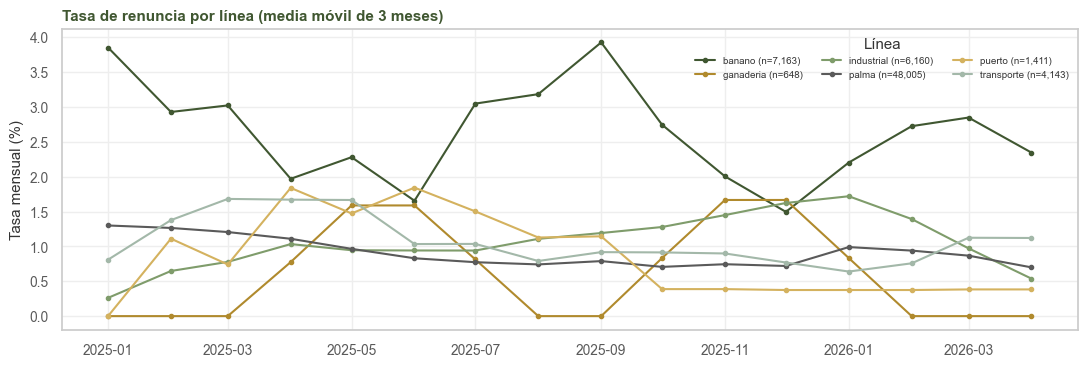

media y desviación mensual de la tasa por línea (%):
            media  desv. entre meses
linea                               
banano       2.55               1.14
ganaderia    0.61               1.09
industrial   1.05               0.46
palma        0.88               0.26
puerto       0.84               1.04
transporte   1.06               0.61


In [10]:
fig, ax = plt.subplots(figsize=(11, 3.8))
for linea, z in tr.groupby('linea'):
    tasa_linea = 100 * z.groupby('mes')[OBJETIVO].mean()
    fechas = pd.PeriodIndex(tasa_linea.index, freq='M').to_timestamp()
    ax.plot(fechas, tasa_linea.rolling(3, min_periods=1).mean(), marker='.',
            label=f'{linea} (n={len(z):,})')
ax.set(title='Tasa de renuncia por línea (media móvil de 3 meses)', ylabel='Tasa mensual (%)')
ax.legend(fontsize=7, ncol=3, title='Línea')
plt.tight_layout()
plt.show()

linea_mes = tr.groupby(['linea', 'mes'])[OBJETIVO].mean().unstack().mul(100)
print('media y desviación mensual de la tasa por línea (%):')
print(pd.DataFrame({'media': linea_mes.mean(1), 'desv. entre meses': linea_mes.std(1)}).round(2)
      .to_string())

Banano tiene la tasa más alta (2,55 % mensual) y también la más variable (desviación de 1,14 puntos
entre meses); palma es la más estable (0,26). Las líneas pequeñas (ganadería, puerto) tienen
desviaciones grandes por tener pocos casos al mes. Las líneas difieren en nivel, y ninguna muestra
una tendencia sostenida.

## Síntesis

- La tasa mensual oscila alrededor de 1 %, sin tendencia y con varianza estable. Enero es el pico
  en los dos años (1,48 % frente a 1,03 %; chi-cuadrado p = 0,0002), por lo que el modelo incluye el
  mes del año, con la advertencia de que solo hay dos eneros.
- ADF y KPSS coinciden en que la serie es estacionaria en nivel, y no hay autocorrelación detectable.
- La deriva de la población se debe al envejecimiento del panel y a un traslado de nómina; contrato,
  línea, oficio y edad son estables. Se espera que el test se parezca al entrenamiento, con más peso
  en antigüedades altas.
- No hay evidencia de deriva del concepto: la relación entre contrato y renuncia y la forma del
  riesgo por antigüedad se mantienen entre periodos.